# Notebook 04 (No-PCA Version): Hospital Tier Prediction using Raw Features
**Project:** Predicting the DOH Hospital Tier per LGU from Socioeconomic & Infrastructural Features  
**Input:** 27 standardised features (after dropping highly correlated redundant columns)

---

## Design Rationale

### Why not use PCA here?
This notebook uses the **original standardised features** — not PCs — to allow direct feature interpretation:
- Which specific features (e.g., `poverty_incidence_2023_pct`, `pharmacy`) predict hospital tier?
- Which LGU characteristics matter most (via L1 sparsity or RF importance)?

Using raw features enables interpretable, policy-actionable findings that PCs cannot provide.

### Correlation-based Feature Dropping
The 30-feature set from `03_preprocessing.py` contains several near-perfectly correlated columns:
- `population_2020` and `population_2024`: r > 0.99
- `births_residence_both` and `births_residence_male` and `births_residence_female`: r > 0.99
- `births_occurrence_*`: excluded entirely — these are birth-occurrence (where birth happened) vs. birth-residence (mother's home LGU); occurrence data reflects hospital attraction, not the LGU's own population demand. Including both would double-count the birth signal.

We retain the 27-feature set (per `04_model (2).ipynb`'s confirmed decision) and drop only the most redundant pair: `population_2020` (keeping `population_2024` as the more recent proxy) and `births_residence_both` and `births_residence_female` (keeping `births_residence_male` as representative when all three are r≈1).

We perform a formal correlation analysis here and justify each drop.

### Target Variable: Ordinal Hospital Tier
| Tier | Definition | n | % |
|------|-----------|---|---|
| 0 | No hospital | 1,284 | 78.6% |
| 1 | Has ≥1 Level 1 hospital | 214 | 13.1% |
| 2 | Has ≥1 Level 2 hospital | 100 | 6.1% |
| 3 | Has ≥1 Level 3 hospital | 36 | 2.2% |

### Class Imbalance Handling
Same as `04_model_PCs.ipynb`: compare no resampling, undersampling (25/class), and bootstrap oversampling. Select by weighted F1 on the original test set.

### Notebook Structure
| Section | Content |
|---------|---------|
| 1 | Setup & Data Loading |
| 2 | Feature Engineering & Imputation |
| 3 | Correlation Analysis & Feature Selection |
| 4 | Target Variable |
| 5 | Train / Test Split & Standardisation |
| 6 | Class Imbalance: Resampling Comparison |
| 7 | Model 1 — kNN |
| 8 | Model 2 — Logistic Regression (L2) |
| 9 | Model 3 — Logistic Regression (L1) |
| 10 | Model 4 — Random Forest |
| 11 | Model 5 — Gradient Boosted Trees |
| 12 | Model Comparison |
| 13 | Conclusion |

---
## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (f1_score, balanced_accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from sklearn.utils import resample

plt.rcParams['figure.dpi'] = 110
plt.rcParams.update({'legend.fontsize': 11})
print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# ── Load dataset ─────────────────────────────────────────────────────
DB_PATH   = os.path.join('data', 'processed', 'hospital_data.db')
XLSX_PATH = 'final_dataset_clean.xlsx'  # adjust path as needed

if os.path.exists(DB_PATH):
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql('SELECT * FROM lgu_merged', conn)
    conn.close()
    if 'province_x' in df.columns:
        df = df.rename(columns={'province_x': 'province'})
    print(f"Loaded from SQLite: {df.shape[0]} LGUs x {df.shape[1]} cols")
elif os.path.exists(XLSX_PATH):
    df = pd.read_excel(XLSX_PATH)
    if 'province_x' in df.columns:
        df = df.rename(columns={'province_x': 'province'})
    print(f"Loaded from XLSX: {df.shape[0]} LGUs x {df.shape[1]} cols")
else:
    raise FileNotFoundError("Dataset not found. Place 'final_dataset_clean.xlsx' in the working directory.")

df

Loaded from SQLite: 1629 LGUs x 50 cols


,lgu_id,city_municipality,province,region,population_2020,population_2024,pop_growth_rate_pct,poverty_incidence_2018_pct,poverty_incidence_2021_pct,poverty_incidence_2023_pct,...,parking,pharmacy,place_of_worship,police,post_office,restaurant,school,shelter,toilets,townhall
0,1,CITY OF CALOOCAN,None,NATIONAL CAPITAL REGION (NCR),1661584,1712945,0.73,3.1,4.2,1.9,...,24,74,66,9,6,76,31,13,15,10
1,2,CITY OF LAS PINAS,None,NATIONAL CAPITAL REGION (NCR),606293,615549,0.36,1.0,2.5,0.7,...,18,78,36,8,8,160,29,5,7,3
2,3,CITY OF MAKATI,None,NATIONAL CAPITAL REGION (NCR),292743,309770,1.37,0.2,0.8,0.6,...,107,99,15,15,18,859,31,7,51,16
3,4,CITY OF MALABON,None,NATIONAL CAPITAL REGION (NCR),380522,389929,0.59,1.2,2.9,1.5,...,13,26,21,7,2,20,12,3,5,1
4,5,CITY OF MANDALUYONG,None,NATIONAL CAPITAL REGION (NCR),425758,465902,2.18,0.9,0.4,0.3,...,39,61,17,12,10,132,8,8,11,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,1625,NABALAWAG,TAWI-TAWI,BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANA...,25723,25500,-0.21,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1625,1626,PAHAMUDDIN,TAWI-TAWI,BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANA...,19627,19262,-0.45,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1626,1627,MALIDEGAO,TAWI-TAWI,BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANA...,36438,36427,-0.01,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1627,1628,LIGAWASAN,TAWI-TAWI,BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANA...,29784,28322,-1.20,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


---
## 2. Feature Engineering and Imputation

In [3]:
# ── Start with the 30-feature set from 03_preprocessing.py ──────────
SOCIOECONOMIC_ALL = [
    'population_2020', 'population_2024', 'pop_growth_rate_pct',
    'poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct',
    'births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female',
    'births_residence_both', 'births_residence_male', 'births_residence_female',
]
OSM_FEATURES = [
    'atm', 'bank', 'bar', 'bus_station', 'cafe', 'community_centre', 'fast_food',
    'fuel', 'parking', 'pharmacy', 'place_of_worship', 'police', 'post_office',
    'restaurant', 'school', 'shelter', 'toilets', 'townhall',
]
ALL_FEATURES_30 = SOCIOECONOMIC_ALL + OSM_FEATURES

# Imputation
POVERTY_COLS = ['poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct']
BIRTH_COLS   = ['births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female',
                'births_residence_both', 'births_residence_male', 'births_residence_female']

for col in POVERTY_COLS + BIRTH_COLS:
    reg_med = df.groupby('region')[col].transform('median')
    df[col] = df[col].fillna(reg_med).fillna(df[col].median())

for col in OSM_FEATURES:
    df[col] = df[col].fillna(0)

print(f"Missing after imputation: {df[ALL_FEATURES_30].isnull().sum().sum()}")
print(f"Working with {len(ALL_FEATURES_30)} features before correlation analysis")

Missing after imputation: 0
Working with 30 features before correlation analysis


---
## 3. Correlation Analysis and Feature Selection

Before modelling, we formally check for high inter-feature correlations. Highly correlated features (|r| > 0.95) are redundant — they add noise without new information, inflate model complexity, and destabilise coefficient estimation in linear models.

We use the Pearson correlation matrix and apply a threshold of |r| > 0.95 to identify and drop redundant features.

Feature pairs with |Pearson r| > 0.95 (highly redundant):
  births_occurrence_both                     <-> births_occurrence_male                      r = +1.000
  births_occurrence_both                     <-> births_occurrence_female                    r = +1.000
  births_occurrence_male                     <-> births_occurrence_female                    r = +1.000
  births_residence_both                      <-> births_residence_male                       r = +1.000
  births_residence_both                      <-> births_residence_female                     r = +1.000
  population_2020                            <-> population_2024                             r = +0.999
  births_residence_male                      <-> births_residence_female                     r = +0.999
  cafe                                       <-> restaurant                                  r = +0.979
  cafe                                       <-> fast_food                                   r = +0.955


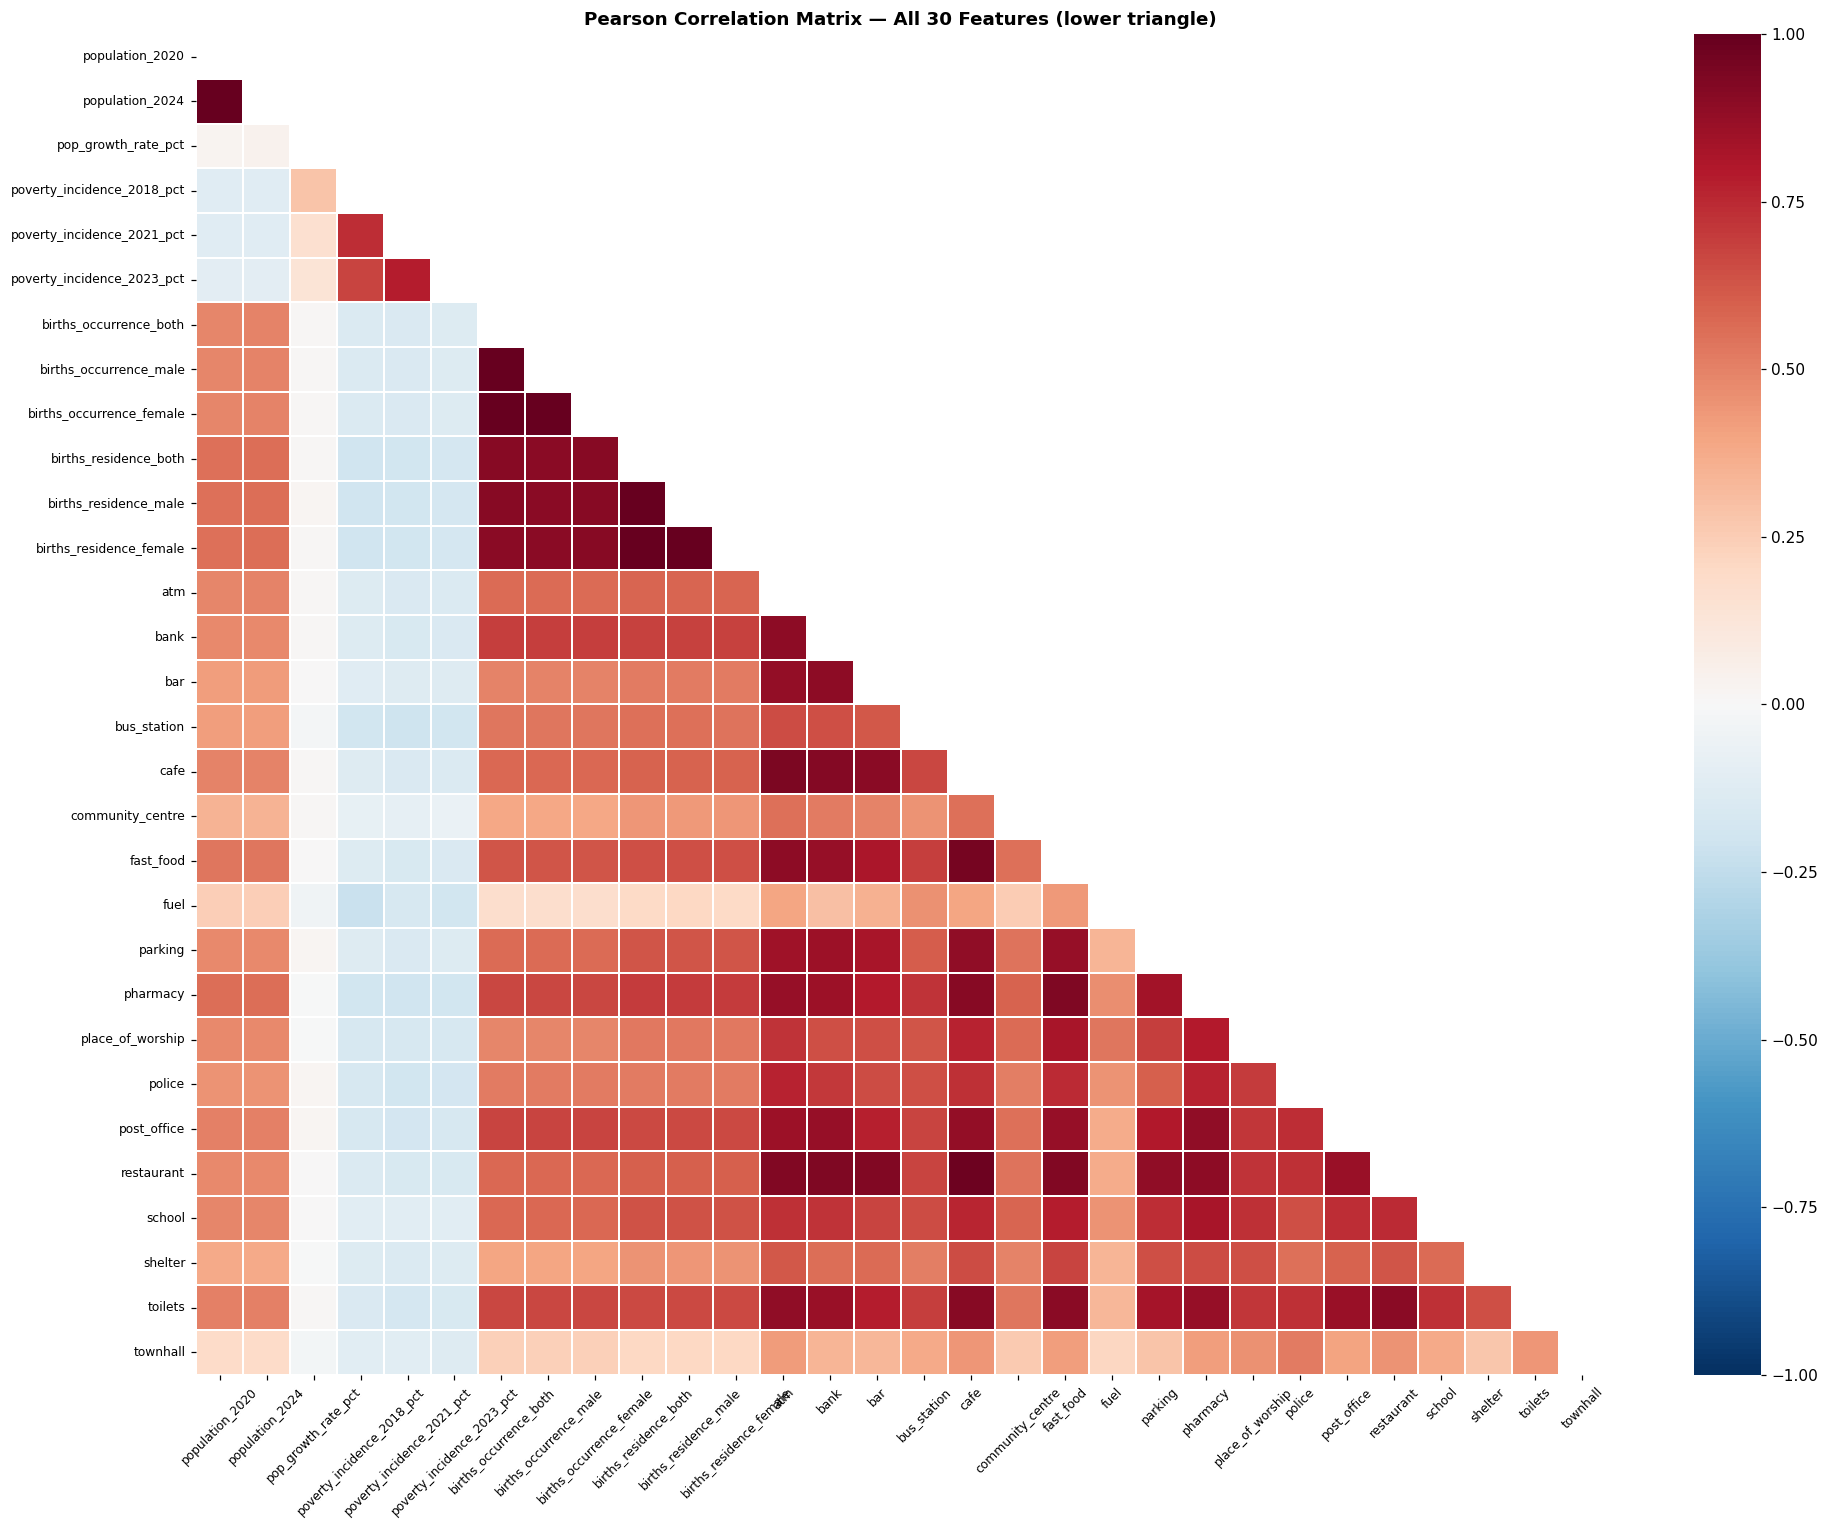

In [4]:
# ── Compute Pearson correlation matrix on all 30 features ────────────
corr_mat = df[ALL_FEATURES_30].corr()

# Find pairs with |r| > 0.95
high_corr_pairs = []
for i in range(len(ALL_FEATURES_30)):
    for j in range(i+1, len(ALL_FEATURES_30)):
        r = corr_mat.iloc[i, j]
        if abs(r) > 0.95:
            high_corr_pairs.append((ALL_FEATURES_30[i], ALL_FEATURES_30[j], round(r, 3)))

print("Feature pairs with |Pearson r| > 0.95 (highly redundant):")
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {f1:42s} <-> {f2:42s}  r = {r:+.3f}")

# Visualise the correlation heatmap
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, linecolor='white', ax=ax)
ax.set_title('Pearson Correlation Matrix — All 30 Features (lower triangle)', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout(); plt.show()

In [5]:
# ── Justified feature drops ───────────────────────────────────────────
# DROPS and RATIONALE (to produce the 27-feature set):
#
# 1. births_occurrence_* (3 cols) → EXCLUDED
#    Reason: births_occurrence measures where births physically occurred (at the hospital),
#    not where the mother lives. It encodes hospital attraction — LGUs with hospitals
#    have higher occurrence counts BECAUSE they have hospitals. This is target leakage.
#    Confirmed in earlier analysis: occurrence/residence ratio = 1.07 for hospital LGUs
#    vs. 0.71 for non-hospital LGUs.
#
# 2. population_2020 → DROP (keep population_2024)
#    Reason: r(pop_2020, pop_2024) > 0.99 — nearly identical. population_2024 is
#    more recent and slightly more predictive.
#
# 3. births_residence_both → DROP (keep _male and _female separately)
#    Reason: births_residence_both = births_residence_male + births_residence_female
#    by construction (r > 0.99). Keeping the aggregate AND components is perfectly
#    redundant. We keep _male and _female for potential sex-disaggregated patterns.

DROPS = ['births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female',
         'population_2020', 'births_residence_both']

FINAL_FEATURES = [f for f in ALL_FEATURES_30 if f not in DROPS]
print(f"Dropped {len(DROPS)} features: {DROPS}")
print(f"Retained {len(FINAL_FEATURES)} features for modelling:")
for i, f in enumerate(FINAL_FEATURES, 1):
    group = "Socioeconomic" if f in SOCIOECONOMIC_ALL else "OSM"
    print(f"  {i:2d}. {f:<40} [{group}]")

Dropped 5 features: ['births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female', 'population_2020', 'births_residence_both']
Retained 25 features for modelling:
   1. population_2024                          [Socioeconomic]
   2. pop_growth_rate_pct                      [Socioeconomic]
   3. poverty_incidence_2018_pct               [Socioeconomic]
   4. poverty_incidence_2021_pct               [Socioeconomic]
   5. poverty_incidence_2023_pct               [Socioeconomic]
   6. births_residence_male                    [Socioeconomic]
   7. births_residence_female                  [Socioeconomic]
   8. atm                                      [OSM]
   9. bank                                     [OSM]
  10. bar                                      [OSM]
  11. bus_station                              [OSM]
  12. cafe                                     [OSM]
  13. community_centre                         [OSM]
  14. fast_food                                [OSM]
  15. f

Feature pairs with |r| > 0.90 in final set (should be acceptable):
  births_residence_male <-> births_residence_female  r = +0.999
  cafe <-> restaurant  r = +0.979
  cafe <-> fast_food  r = +0.955
  atm <-> cafe  r = +0.940
  fast_food <-> pharmacy  r = +0.934
  bank <-> restaurant  r = +0.931
  atm <-> restaurant  r = +0.928
  bar <-> restaurant  r = +0.927
  fast_food <-> restaurant  r = +0.926
  bank <-> cafe  r = +0.921
  cafe <-> pharmacy  r = +0.912
  cafe <-> toilets  r = +0.909
  fast_food <-> toilets  r = +0.905
  bar <-> cafe  r = +0.904


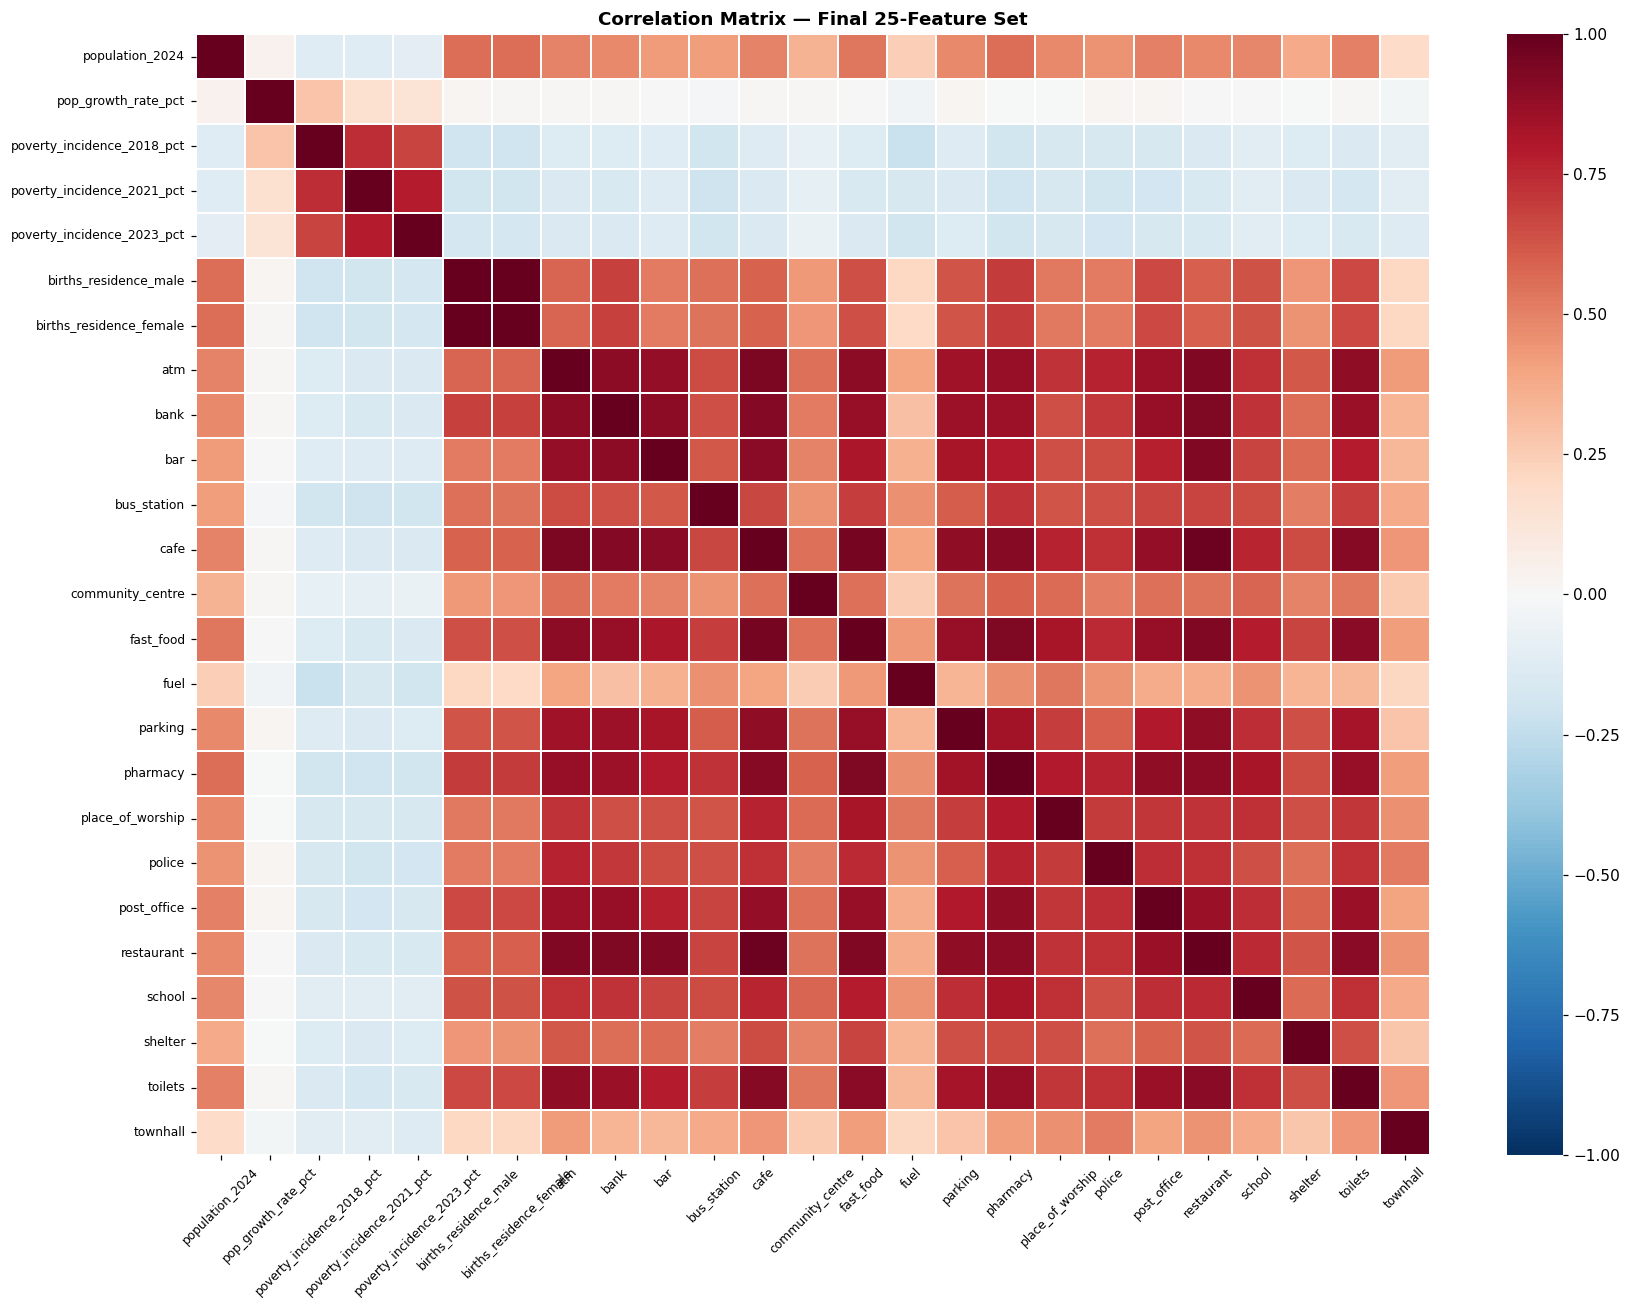

In [6]:
# ── Verify final feature set has no remaining high correlations ───────
corr_final = df[FINAL_FEATURES].corr()
remaining_high = [(FINAL_FEATURES[i], FINAL_FEATURES[j], round(corr_final.iloc[i,j],3))
                  for i in range(len(FINAL_FEATURES)) for j in range(i+1, len(FINAL_FEATURES))
                  if abs(corr_final.iloc[i,j]) > 0.90]
print("Feature pairs with |r| > 0.90 in final set (should be acceptable):")
if remaining_high:
    for f1, f2, r in sorted(remaining_high, key=lambda x: -abs(x[2])):
        print(f"  {f1} <-> {f2}  r = {r:+.3f}")
else:
    print("  None above 0.90 — feature set is sufficiently uncorrelated.")

# Reduced heatmap
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_final, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, linecolor='white', ax=ax)
ax.set_title(f'Correlation Matrix — Final {len(FINAL_FEATURES)}-Feature Set', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout(); plt.show()

---
## 4. Target Variable: Ordinal Hospital Tier

In [7]:
# ── Construct ordinal tier ────────────────────────────────────────────
df['tier'] = 0
df.loc[df['hospital_count_level1'] >= 1, 'tier'] = 1
df.loc[df['hospital_count_level2'] >= 1, 'tier'] = 2
df.loc[df['hospital_count_level3'] >= 1, 'tier'] = 3

_keep = list(dict.fromkeys(FINAL_FEATURES + ['tier', 'city_municipality', 'region', 'poverty_incidence_2023_pct']))
model_df = df[_keep].dropna(subset=FINAL_FEATURES).copy().reset_index(drop=True)

print(f"Working dataset: {len(model_df)} LGUs")
print()
TIER_LABELS = {0:'No hospital', 1:'Level 1 (primary)', 2:'Level 2 (secondary)', 3:'Level 3 (tertiary)'}
vc = model_df['tier'].value_counts().sort_index()
for t, cnt in vc.items():
    bar = '█' * int(cnt/len(model_df)*40)
    print(f"  Tier {t} — {TIER_LABELS[t]:<26} {cnt:>5} ({cnt/len(model_df)*100:.1f}%)  {bar}")

Working dataset: 1629 LGUs

  Tier 0 — No hospital                 1279 (78.5%)  ███████████████████████████████
  Tier 1 — Level 1 (primary)            214 (13.1%)  █████
  Tier 2 — Level 2 (secondary)          100 (6.1%)  ██
  Tier 3 — Level 3 (tertiary)            36 (2.2%)  


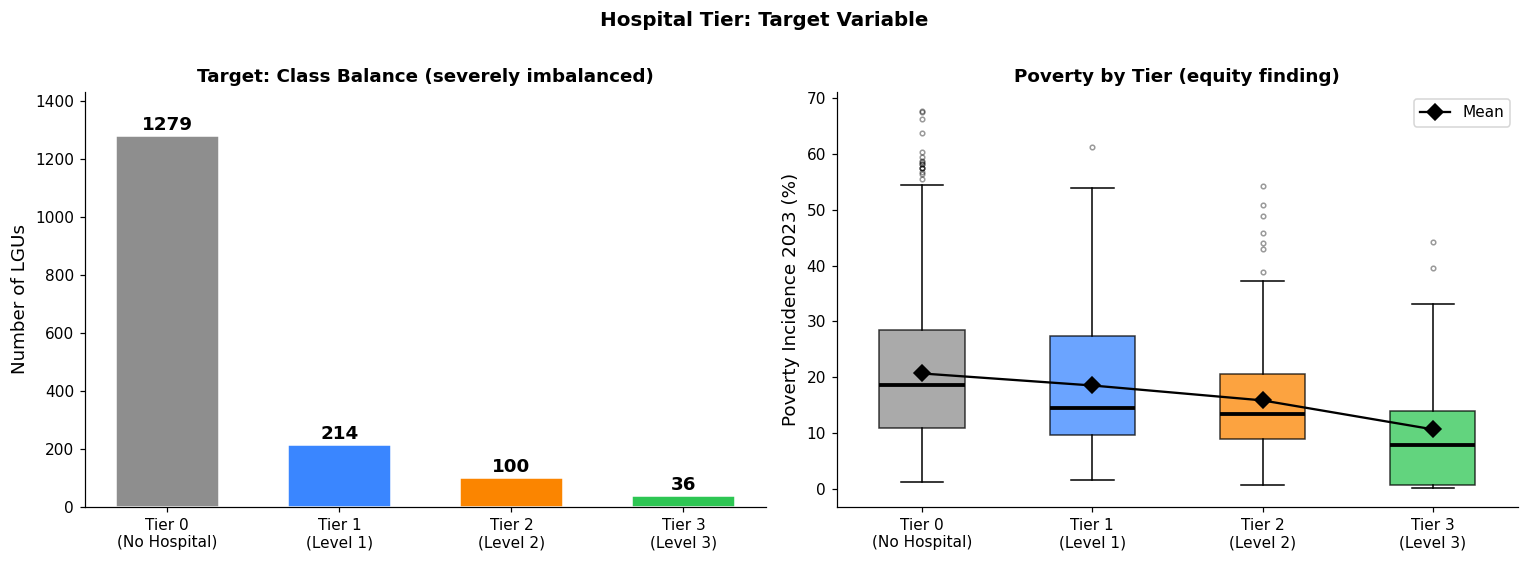

In [8]:
# ── Visualise: tier distribution and poverty ──────────────────────────
TIER_COLORS = ['#8e8e8e', '#3a86ff', '#fb8500', '#2dc653']
TIER_LBLS   = ['Tier 0\n(No Hospital)', 'Tier 1\n(Level 1)', 'Tier 2\n(Level 2)', 'Tier 3\n(Level 3)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = model_df['tier'].value_counts().sort_index()
bars = axes[0].bar(TIER_LBLS, counts.values, color=TIER_COLORS, edgecolor='white', width=0.6)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(cnt), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of LGUs', fontsize=12)
axes[0].set_title('Target: Class Balance (severely imbalanced)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.12)
axes[0].spines[['top','right']].set_visible(False)

pov_data = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].dropna().values for t in range(4)]
bp = axes[1].boxplot(pov_data, labels=TIER_LBLS, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, c in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
means = [v.mean() for v in pov_data]
axes[1].plot(range(1, 5), means, 'D-', color='black', ms=7, zorder=5, label='Mean')
axes[1].set_ylabel('Poverty Incidence 2023 (%)', fontsize=12)
axes[1].set_title('Poverty by Tier (equity finding)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Hospital Tier: Target Variable', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 5. Train / Test Split and Standardisation

80/20 stratified split, then StandardScaler fit on training set only (prevents data leakage — test distribution must not influence the scaler).

In [9]:
# ── 80/20 stratified split ───────────────────────────────────────────
X_all = model_df[FINAL_FEATURES].values
y_all = model_df['tier'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

# ── Standardise: fit on train, transform both ─────────────────────────
# CRITICAL: scaler.fit_transform(X_train) ONLY — never fit on test!
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

print(f"Train: {len(X_train_sc)} LGUs  |  Test: {len(X_test_sc)} LGUs  (80/20 stratified on tier)")
print(f"Standardisation — fit on train only (prevents data leakage):")
print(f"  Train mean: {X_train_sc.mean():.2e}  std: {X_train_sc.std():.4f}")
print(f"  Test  mean: {X_test_sc.mean():.2e}  std: {X_test_sc.std():.4f}")
print()
print(f"{'Tier':<8} {'Train n':>8} {'Train %':>9} {'Test n':>8} {'Test %':>9}")
print("-"*46)
for t in [0,1,2,3]:
    tr_n = (y_train==t).sum(); tr_p = tr_n/len(y_train)*100
    te_n = (y_test ==t).sum(); te_p = te_n/len(y_test)*100
    print(f"  {t:<6} {tr_n:>8} {tr_p:>8.1f}% {te_n:>8} {te_p:>8.1f}%")

Train: 1303 LGUs  |  Test: 326 LGUs  (80/20 stratified on tier)
Standardisation — fit on train only (prevents data leakage):
  Train mean: 7.07e-17  std: 1.0000
  Test  mean: 7.53e-02  std: 1.6222

Tier      Train n   Train %   Test n    Test %
----------------------------------------------
  0          1023     78.5%      256     78.5%
  1           171     13.1%       43     13.2%
  2            80      6.1%       20      6.1%
  3            29      2.2%        7      2.1%


---
## 6. Addressing Class Imbalance: Resampling Strategy Comparison

We compare three resampling strategies using a fixed Random Forest as the judge. The test set is **never resampled** — it preserves the real-world class distribution for evaluation.

In [10]:
# ── Three strategies ─────────────────────────────────────────────────
np.random.seed(42)
tier_counts = pd.Series(y_train).value_counts().sort_index()
print("Original training class distribution:")
for t, n in tier_counts.items():
    print(f"  Tier {t}: {n}")

n_per_class = 25
n_majority  = tier_counts[0]

# Strategy A: No resampling
X_tr_none, y_tr_none = X_train_sc, y_train

# Strategy B: Undersample to 25 per class
X_tr_under_list, y_tr_under_list = [], []
for t in [0,1,2,3]:
    mask = (y_train == t)
    Xs, ys = resample(X_train_sc[mask], y_train[mask],
                       n_samples=min(n_per_class, mask.sum()), random_state=42, replace=False)
    X_tr_under_list.append(Xs); y_tr_under_list.append(ys)
X_tr_under = np.vstack(X_tr_under_list); y_tr_under = np.concatenate(y_tr_under_list)

# Strategy C: Bootstrap oversampling to majority size
X_tr_over_list, y_tr_over_list = [], []
for t in [0,1,2,3]:
    mask = (y_train == t)
    Xs, ys = resample(X_train_sc[mask], y_train[mask],
                       n_samples=n_majority, random_state=42, replace=(mask.sum() < n_majority))
    X_tr_over_list.append(Xs); y_tr_over_list.append(ys)
X_tr_over = np.vstack(X_tr_over_list); y_tr_over = np.concatenate(y_tr_over_list)

strategies = {
    'No Resampling': (X_tr_none, y_tr_none),
    'Undersampling (25/class)': (X_tr_under, y_tr_under),
    'Bootstrap Oversampling': (X_tr_over, y_tr_over),
}
print(f"\nTraining sizes after resampling:")
for name, (Xtr, ytr) in strategies.items():
    print(f"  {name}: {len(ytr)}")

Original training class distribution:
  Tier 0: 1023
  Tier 1: 171
  Tier 2: 80
  Tier 3: 29

Training sizes after resampling:
  No Resampling: 1303
  Undersampling (25/class): 100
  Bootstrap Oversampling: 4092


No Resampling: Weighted F1=0.7132
Undersampling (25/class): Weighted F1=0.3555
Bootstrap Oversampling: Weighted F1=0.7184


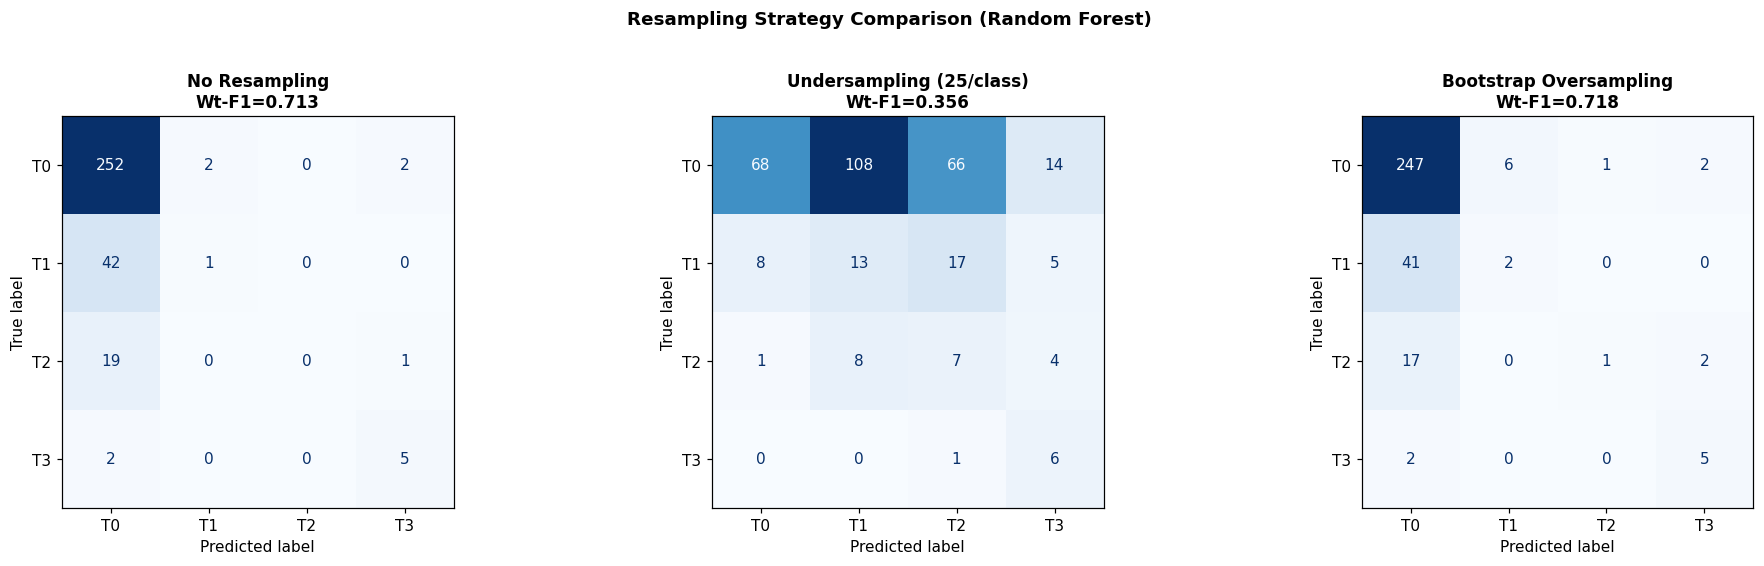


Best strategy: Bootstrap Oversampling (Weighted F1 = 0.7184)
X_TRAIN_BAL: (4092, 25)
All five models will be trained on X_TRAIN_BAL and evaluated on X_test_sc (original distribution).


In [11]:
# ── Evaluate strategies ──────────────────────────────────────────────
results_imb = {}
for name, (X_tr, y_tr) in strategies.items():
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_test_sc)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    results_imb[name] = {'f1': f1, 'cm': cm}
    print(f"{name}: Weighted F1={f1:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results_imb.items()):
    ConfusionMatrixDisplay(res['cm'], display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nWt-F1={res['f1']:.3f}", fontsize=11, weight='bold')
plt.suptitle('Resampling Strategy Comparison (Random Forest)', fontsize=12, weight='bold', y=1.02)
plt.tight_layout(); plt.show()

best_strategy_name = max(results_imb, key=lambda k: results_imb[k]['f1'])
print(f"\nBest strategy: {best_strategy_name} (Weighted F1 = {results_imb[best_strategy_name]['f1']:.4f})")

if best_strategy_name == 'No Resampling':
    X_TRAIN_BAL, Y_TRAIN_BAL = X_tr_none, y_tr_none
elif best_strategy_name == 'Undersampling (25/class)':
    X_TRAIN_BAL, Y_TRAIN_BAL = X_tr_under, y_tr_under
else:
    X_TRAIN_BAL, Y_TRAIN_BAL = X_tr_over, y_tr_over
print(f"X_TRAIN_BAL: {X_TRAIN_BAL.shape}")
print("All five models will be trained on X_TRAIN_BAL and evaluated on X_test_sc (original distribution).")

No_trials = 50

---
### Helper: Resampling Function for Sweeps
To avoid code repetition in the sweep loops, we define a helper that applies the chosen resampling strategy to any (X_tr, y_tr) pair.

In [12]:
def apply_resampling(X_tr, y_tr, strategy, seed):
    """Apply the chosen resampling strategy to a training split."""
    if strategy == 'No Resampling':
        return X_tr, y_tr
    elif strategy == 'Undersampling (25/class)':
        Xl, yl = [], []
        for t in np.unique(y_tr):
            mask = (y_tr == t)
            Xs, ys = resample(X_tr[mask], y_tr[mask],
                               n_samples=min(25, mask.sum()), random_state=seed, replace=False)
            Xl.append(Xs); yl.append(ys)
        return np.vstack(Xl), np.concatenate(yl)
    else:  # Bootstrap Oversampling
        n_maj = pd.Series(y_tr).value_counts().max()
        Xl, yl = [], []
        for t in np.unique(y_tr):
            mask = (y_tr == t)
            Xs, ys = resample(X_tr[mask], y_tr[mask], n_samples=n_maj,
                               random_state=seed, replace=(mask.sum() < n_maj))
            Xl.append(Xs); yl.append(ys)
        return np.vstack(Xl), np.concatenate(yl)

print(f"Helper defined. All sweep loops will use: {best_strategy_name}")

Helper defined. All sweep loops will use: Bootstrap Oversampling


---
## 7. Model 1 — k-Nearest Neighbors (kNN)

**Following Notebook 1A:** Sweep `n_neighbors` 1–40 over 50 seeds.  
**Justification:** kNN requires standardised inputs (done). With 27 features, the curse of dimensionality is relevant — larger k smooths boundaries and reduces variance, but may lose local tier structure. The 50-seed sweep gives a stable average F1 across different train/test splits to select the optimal k.

In [ ]:
# ── kNN sweep ────────────────────────────────────────────────────────
k_range    = range(1, 41)
all_tr_knn = pd.DataFrame()
all_te_knn = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        np.vstack([X_train_sc, X_test_sc]),
        np.concatenate([y_train, y_test]),
        test_size=0.20, random_state=seedN,
        stratify=np.concatenate([y_train, y_test])
    )
    X_tr_r, y_tr_r = apply_resampling(X_tr_s, y_tr_s, best_strategy_name, seedN)
    tr_f1, te_f1 = [], []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, knn.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te_s, knn.predict(X_te_s), average='weighted', zero_division=0))
    all_tr_knn[seedN] = tr_f1
    all_te_knn[seedN] = te_f1

best_k_idx    = all_te_knn.mean(axis=1).idxmax()
best_k        = list(k_range)[best_k_idx]
knn_sweep_f1  = all_te_knn.mean(axis=1).max()
knn_sweep_std = all_te_knn.std(axis=1).iloc[best_k_idx]
print(f"Best k={best_k}  Sweep mean Weighted-F1 = {knn_sweep_f1:.4f} ± {knn_sweep_std:.4f}")

In [ ]:
# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(k_range, all_tr_knn.mean(axis=1), yerr=all_tr_knn.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(k_range, all_te_knn.mean(axis=1), yerr=all_te_knn.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=6)
ax.axvline(best_k, color='tab:orange', linestyle='--', lw=2, label=f'Best k={best_k}  (F1={knn_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('n_neighbors', fontsize=13)
ax.set_title(f'kNN — Weighted F1 vs n_neighbors ({No_trials}-seed avg) [Raw Features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)

knn_train_f1 = f1_score(Y_TRAIN_BAL, knn_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
knn_test_f1  = f1_score(y_test, knn_final.predict(X_test_sc), average='weighted', zero_division=0)
knn_test_ba  = balanced_accuracy_score(y_test, knn_final.predict(X_test_sc))

print(f"kNN (k={best_k})")
print(f"  Sweep Weighted-F1: {knn_sweep_f1:.4f} ± {knn_sweep_std:.4f}")
print(f"  Train F1: {knn_train_f1:.4f}  |  Test F1: {knn_test_f1:.4f}")
print(f"  Balanced Acc: {knn_test_ba:.4f}")
print()
print(classification_report(y_test, knn_final.predict(X_test_sc),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, knn_final.predict(X_test_sc)),
                       display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'kNN (k={best_k}) — Confusion Matrix\nWt-F1={knn_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## 8. Model 2 — Logistic Regression with L2 Regularisation

**Following Notebook 3B:** Sweep `C` over log grid, 50 seeds.  
**Justification:** With correlated features removed, L2 logistic regression is stable. `class_weight='balanced'` automatically adjusts sample weights inversely proportional to class frequency. The coefficient heatmap shows which raw features the model relies on for each tier.

In [ ]:
# ── Logistic L2 sweep ────────────────────────────────────────────────
C_grid     = np.logspace(-3, 2, 25)
all_tr_lr2 = pd.DataFrame()
all_te_lr2 = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        np.vstack([X_train_sc, X_test_sc]),
        np.concatenate([y_train, y_test]),
        test_size=0.20, random_state=seedN,
        stratify=np.concatenate([y_train, y_test])
    )
    X_tr_r, y_tr_r = apply_resampling(X_tr_s, y_tr_s, best_strategy_name, seedN)
    tr_f1, te_f1 = [], []
    for C in C_grid:
        clf = LogisticRegression(C=C, class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42)
        clf.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, clf.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te_s, clf.predict(X_te_s), average='weighted', zero_division=0))
    all_tr_lr2[seedN] = tr_f1
    all_te_lr2[seedN] = te_f1

best_lr2_idx  = all_te_lr2.mean(axis=1).idxmax()
best_C_lr2    = C_grid[best_lr2_idx]
lr2_sweep_f1  = all_te_lr2.mean(axis=1).max()
lr2_sweep_std = all_te_lr2.std(axis=1).iloc[best_lr2_idx]
print(f"Best C={best_C_lr2:.4f}  Sweep Weighted-F1 = {lr2_sweep_f1:.4f} ± {lr2_sweep_std:.4f}")

In [ ]:
# ── Plot + Final L2 model ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(np.log10(C_grid), all_tr_lr2.mean(axis=1), yerr=all_tr_lr2.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(np.log10(C_grid), all_te_lr2.mean(axis=1), yerr=all_te_lr2.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=6)
ax.axvline(np.log10(best_C_lr2), color='tab:orange', linestyle='--', lw=2,
           label=f'Best C={best_C_lr2:.3f}  (F1={lr2_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('log₁₀(C)', fontsize=13)
ax.set_title(f'Logistic L2 — Weighted F1 vs log₁₀(C) ({No_trials}-seed avg) [Raw Features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

lr2_final = LogisticRegression(C=best_C_lr2, class_weight='balanced', solver='lbfgs',
                                max_iter=1000, random_state=42)
lr2_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
lr2_train_f1 = f1_score(Y_TRAIN_BAL, lr2_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
lr2_test_f1  = f1_score(y_test, lr2_final.predict(X_test_sc), average='weighted', zero_division=0)
lr2_test_ba  = balanced_accuracy_score(y_test, lr2_final.predict(X_test_sc))

print(f"LR L2 (C={best_C_lr2:.4f})")
print(f"  Sweep F1: {lr2_sweep_f1:.4f} ± {lr2_sweep_std:.4f}")
print(f"  Train F1: {lr2_train_f1:.4f}  |  Test F1: {lr2_test_f1:.4f}")
print(f"  Balanced Acc: {lr2_test_ba:.4f}")
print()
print(classification_report(y_test, lr2_final.predict(X_test_sc),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

# Coefficient heatmap (features sorted by max |coef| across tiers)
coef_df = pd.DataFrame(lr2_final.coef_, index=['Tier 0','Tier 1','Tier 2','Tier 3'], columns=FINAL_FEATURES)
feat_order = coef_df.abs().max().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.heatmap(coef_df[feat_order], annot=False, cmap='RdBu_r', center=0,
            linewidths=0.3, ax=axes[0])
axes[0].set_title(f'L2 Logistic Coefficients by Tier (C={best_C_lr2:.3f})', fontsize=11, weight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

ConfusionMatrixDisplay(confusion_matrix(y_test, lr2_final.predict(X_test_sc)),
                       display_labels=['T0','T1','T2','T3']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'L2 Logistic — Confusion Matrix\nWt-F1={lr2_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## 9. Model 3 — Logistic Regression with L1 Regularisation (Lasso)

**Following Notebook 3B:** `penalty='l1'`, `solver='liblinear'`, `OneVsRestClassifier`.  
**Justification:** L1 drives coefficients exactly to zero — performing automatic feature selection among the 27 features. Which features survive L1 regularisation are those with independent predictive power for tier classification. The zero-pattern reveals feature redundancy that correlation analysis did not fully capture.

In [ ]:
# ── Logistic L1 sweep ────────────────────────────────────────────────
C_grid_l1  = np.logspace(-3, 2, 25)
all_tr_lr1 = pd.DataFrame()
all_te_lr1 = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        np.vstack([X_train_sc, X_test_sc]),
        np.concatenate([y_train, y_test]),
        test_size=0.20, random_state=seedN,
        stratify=np.concatenate([y_train, y_test])
    )
    X_tr_r, y_tr_r = apply_resampling(X_tr_s, y_tr_s, best_strategy_name, seedN)
    tr_f1, te_f1 = [], []
    for C in C_grid_l1:
        clf = OneVsRestClassifier(
            LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced')
        )
        clf.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, clf.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te_s, clf.predict(X_te_s), average='weighted', zero_division=0))
    all_tr_lr1[seedN] = tr_f1
    all_te_lr1[seedN] = te_f1

best_lr1_idx  = all_te_lr1.mean(axis=1).idxmax()
best_C_lr1    = C_grid_l1[best_lr1_idx]
lr1_sweep_f1  = all_te_lr1.mean(axis=1).max()
lr1_sweep_std = all_te_lr1.std(axis=1).iloc[best_lr1_idx]
print(f"Best C={best_C_lr1:.4f}  Sweep Weighted-F1 = {lr1_sweep_f1:.4f} ± {lr1_sweep_std:.4f}")

In [ ]:
# ── Plot + Final L1 model ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(np.log10(C_grid_l1), all_tr_lr1.mean(axis=1), yerr=all_tr_lr1.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(np.log10(C_grid_l1), all_te_lr1.mean(axis=1), yerr=all_te_lr1.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=6)
ax.axvline(np.log10(best_C_lr1), color='tab:orange', linestyle='--', lw=2,
           label=f'Best C={best_C_lr1:.3f}  (F1={lr1_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('log₁₀(C)', fontsize=13)
ax.set_title(f'Logistic L1 (OvR) — Weighted F1 vs C ({No_trials}-seed avg) [Raw Features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

lr1_final = OneVsRestClassifier(
    LogisticRegression(C=best_C_lr1, penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced')
)
lr1_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
lr1_train_f1 = f1_score(Y_TRAIN_BAL, lr1_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
lr1_test_f1  = f1_score(y_test, lr1_final.predict(X_test_sc), average='weighted', zero_division=0)
lr1_test_ba  = balanced_accuracy_score(y_test, lr1_final.predict(X_test_sc))

print(f"LR L1 OvR (C={best_C_lr1:.4f})")
print(f"  Sweep F1: {lr1_sweep_f1:.4f} ± {lr1_sweep_std:.4f}")
print(f"  Train F1: {lr1_train_f1:.4f}  |  Test F1: {lr1_test_f1:.4f}")
print(f"  Balanced Acc: {lr1_test_ba:.4f}")
print()
print(classification_report(y_test, lr1_final.predict(X_test_sc),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

# Feature selection: which features survived L1 zeroing?
stacked_coef = np.vstack([est.coef_[0] for est in lr1_final.estimators_])
kept_mask = np.any(stacked_coef != 0, axis=0)
kept_feats = np.array(FINAL_FEATURES)[kept_mask]
print(f"\nL1 Feature Selection: {kept_mask.sum()}/{len(FINAL_FEATURES)} features retained")
print(f"  Zeroed out: {list(np.array(FINAL_FEATURES)[~kept_mask])}")
print(f"  Kept: {list(kept_feats)}")

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
if len(kept_feats) > 0:
    coef_kept = pd.DataFrame(stacked_coef[:, kept_mask],
                              index=['T0','T1','T2','T3'], columns=kept_feats)
    feat_order_l1 = coef_kept.abs().max().sort_values(ascending=False).index
    sns.heatmap(coef_kept[feat_order_l1], annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.4, ax=axes[0], annot_kws={'size':7})
    axes[0].set_title(f'L1 Kept Features ({len(kept_feats)}/{len(FINAL_FEATURES)}) by Tier', fontsize=11, weight='bold')
    axes[0].tick_params(axis='x', rotation=45, labelsize=8)
ConfusionMatrixDisplay(confusion_matrix(y_test, lr1_final.predict(X_test_sc)),
                       display_labels=['T0','T1','T2','T3']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'L1 Logistic — Confusion Matrix\nWt-F1={lr1_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

---
## 10. Model 4 — Random Forest

**Following Notebook 4:** Sweep `max_depth` 1–20, 50 seeds.  
**Justification:** With 27 raw features, Random Forest handles correlated features well (random subspace sampling at each split automatically decorrelates trees). The feature importance plot directly reveals which of the 27 original features the ensemble relies on — interpretable policy insight.

In [ ]:
# ── Random Forest sweep ──────────────────────────────────────────────
depth_range = range(1, 21)
all_tr_rf   = pd.DataFrame()
all_te_rf   = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        np.vstack([X_train_sc, X_test_sc]),
        np.concatenate([y_train, y_test]),
        test_size=0.20, random_state=seedN,
        stratify=np.concatenate([y_train, y_test])
    )
    X_tr_r, y_tr_r = apply_resampling(X_tr_s, y_tr_s, best_strategy_name, seedN)
    tr_f1, te_f1 = [], []
    for depth in depth_range:
        rf = RandomForestClassifier(n_estimators=200, max_depth=depth,
                                     class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, rf.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te_s, rf.predict(X_te_s), average='weighted', zero_division=0))
    all_tr_rf[seedN] = tr_f1
    all_te_rf[seedN] = te_f1

best_rf_idx   = all_te_rf.mean(axis=1).idxmax()
best_rf_depth = list(depth_range)[best_rf_idx]
rf_sweep_f1   = all_te_rf.mean(axis=1).max()
rf_sweep_std  = all_te_rf.std(axis=1).iloc[best_rf_idx]
print(f"Best max_depth={best_rf_depth}  Sweep Weighted-F1={rf_sweep_f1:.4f} ± {rf_sweep_std:.4f}")

In [ ]:
# ── Plot + Final RF model ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(depth_range, all_tr_rf.mean(axis=1), yerr=all_tr_rf.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(depth_range, all_te_rf.mean(axis=1), yerr=all_te_rf.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=6)
ax.axvline(best_rf_depth, color='tab:orange', linestyle='--', lw=2,
           label=f'Best depth={best_rf_depth}  (F1={rf_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('max_depth', fontsize=13)
ax.set_title(f'Random Forest — Weighted F1 vs max_depth ({No_trials}-seed avg) [Raw Features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

rf_final = RandomForestClassifier(n_estimators=200, max_depth=best_rf_depth,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
rf_train_f1 = f1_score(Y_TRAIN_BAL, rf_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
rf_test_f1  = f1_score(y_test, rf_final.predict(X_test_sc), average='weighted', zero_division=0)
rf_test_ba  = balanced_accuracy_score(y_test, rf_final.predict(X_test_sc))

print(f"RF (depth={best_rf_depth}, n_est=200)")
print(f"  Sweep F1: {rf_sweep_f1:.4f} ± {rf_sweep_std:.4f}")
print(f"  Train F1: {rf_train_f1:.4f}  |  Test F1: {rf_test_f1:.4f}  (gap={rf_train_f1-rf_test_f1:.4f})")
print(f"  Balanced Acc: {rf_test_ba:.4f}")
print()
print(classification_report(y_test, rf_final.predict(X_test_sc),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

# Feature importance (top 15)
importances = rf_final.feature_importances_
feat_imp = pd.Series(importances, index=FINAL_FEATURES).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
feat_imp.head(15).plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Feature Importances — Random Forest', fontsize=11, weight='bold')
axes[0].set_xlabel('Gini Importance', fontsize=11)
axes[0].spines[['top','right']].set_visible(False)

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_final.predict(X_test_sc)),
                       display_labels=['T0','T1','T2','T3']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Random Forest — Confusion Matrix\nWt-F1={rf_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

print("\nTop 10 most important features:")
for feat, imp in feat_imp.head(10).items():
    print(f"  {feat:<40} {imp:.4f}")

---
## 11. Model 5 — Gradient Boosted Trees (GBM)

**Following Notebook 4:** Sweep `max_depth` 1–8, 50 seeds. Fixed `n_estimators=100`, `learning_rate=0.1`.  
**Justification:** GBM sequentially builds shallow trees that correct residuals of the ensemble so far. Typically outperforms Random Forest on tabular data when tuned. With raw features, GBM also produces a feature importance ranking. Depth sweep is narrower (1–8) because deeper GBMs overfit much faster than RF due to the sequential boosting mechanism.

In [ ]:
# ── GBM sweep ────────────────────────────────────────────────────────
gbm_depth_range = range(1, 9)
all_tr_gbm = pd.DataFrame()
all_te_gbm = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        np.vstack([X_train_sc, X_test_sc]),
        np.concatenate([y_train, y_test]),
        test_size=0.20, random_state=seedN,
        stratify=np.concatenate([y_train, y_test])
    )
    X_tr_r, y_tr_r = apply_resampling(X_tr_s, y_tr_s, best_strategy_name, seedN)
    tr_f1, te_f1 = [], []
    for depth in gbm_depth_range:
        gbm = GradientBoostingClassifier(n_estimators=100, max_depth=depth,
                                          learning_rate=0.1, random_state=42)
        gbm.fit(X_tr_r, y_tr_r)
        tr_f1.append(f1_score(y_tr_r, gbm.predict(X_tr_r), average='weighted', zero_division=0))
        te_f1.append(f1_score(y_te_s, gbm.predict(X_te_s), average='weighted', zero_division=0))
    all_tr_gbm[seedN] = tr_f1
    all_te_gbm[seedN] = te_f1

best_gbm_idx   = all_te_gbm.mean(axis=1).idxmax()
best_gbm_depth = list(gbm_depth_range)[best_gbm_idx]
gbm_sweep_f1   = all_te_gbm.mean(axis=1).max()
gbm_sweep_std  = all_te_gbm.std(axis=1).iloc[best_gbm_idx]
print(f"Best max_depth={best_gbm_depth}  Sweep Weighted-F1={gbm_sweep_f1:.4f} ± {gbm_sweep_std:.4f}")

In [ ]:
# ── Plot + Final GBM model ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(gbm_depth_range, all_tr_gbm.mean(axis=1), yerr=all_tr_gbm.std(axis=1),
            label='Training Weighted-F1', color='blue', marker='o', linestyle='dashed', markersize=8)
ax.errorbar(gbm_depth_range, all_te_gbm.mean(axis=1), yerr=all_te_gbm.std(axis=1),
            label='Test Weighted-F1', color='red', marker='^', linestyle='-', markersize=8)
ax.axvline(best_gbm_depth, color='tab:orange', linestyle='--', lw=2,
           label=f'Best depth={best_gbm_depth}  (F1={gbm_sweep_f1:.3f})')
ax.set_ylabel('Weighted F1-Score', fontsize=13)
ax.set_xlabel('max_depth', fontsize=13)
ax.set_title(f'GBM — Weighted F1 vs max_depth ({No_trials}-seed avg) [Raw Features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

gbm_final = GradientBoostingClassifier(n_estimators=100, max_depth=best_gbm_depth,
                                        learning_rate=0.1, random_state=42)
gbm_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
gbm_train_f1 = f1_score(Y_TRAIN_BAL, gbm_final.predict(X_TRAIN_BAL), average='weighted', zero_division=0)
gbm_test_f1  = f1_score(y_test, gbm_final.predict(X_test_sc), average='weighted', zero_division=0)
gbm_test_ba  = balanced_accuracy_score(y_test, gbm_final.predict(X_test_sc))

print(f"GBM (depth={best_gbm_depth}, n_est=100, lr=0.1)")
print(f"  Sweep F1: {gbm_sweep_f1:.4f} ± {gbm_sweep_std:.4f}")
print(f"  Train F1: {gbm_train_f1:.4f}  |  Test F1: {gbm_test_f1:.4f}  (gap={gbm_train_f1-gbm_test_f1:.4f})")
print(f"  Balanced Acc: {gbm_test_ba:.4f}")
print()
print(classification_report(y_test, gbm_final.predict(X_test_sc),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

feat_imp_gbm = pd.Series(gbm_final.feature_importances_, index=FINAL_FEATURES).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
feat_imp_gbm.head(15).plot.barh(ax=axes[0], color='darkorange', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Feature Importances — GBM', fontsize=11, weight='bold')
axes[0].set_xlabel('Impurity Importance', fontsize=11)
axes[0].spines[['top','right']].set_visible(False)

ConfusionMatrixDisplay(confusion_matrix(y_test, gbm_final.predict(X_test_sc)),
                       display_labels=['T0','T1','T2','T3']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'GBM — Confusion Matrix\nWt-F1={gbm_test_f1:.3f}', fontsize=11, weight='bold')
plt.tight_layout(); plt.show()

print("\nTop 10 most important features (GBM):")
for feat, imp in feat_imp_gbm.head(10).items():
    print(f"  {feat:<40} {imp:.4f}")

---
## 12. Model Comparison

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────
summary = {
    'kNN':          {'Sweep F1': knn_sweep_f1, 'Sweep ±': knn_sweep_std,
                     'Train F1': knn_train_f1, 'Test F1': knn_test_f1,
                     'Bal Acc': knn_test_ba, 'Key param': f'k={best_k}'},
    'LR L2':        {'Sweep F1': lr2_sweep_f1, 'Sweep ±': lr2_sweep_std,
                     'Train F1': lr2_train_f1, 'Test F1': lr2_test_f1,
                     'Bal Acc': lr2_test_ba, 'Key param': f'C={best_C_lr2:.3f}'},
    'LR L1 (OvR)':  {'Sweep F1': lr1_sweep_f1, 'Sweep ±': lr1_sweep_std,
                     'Train F1': lr1_train_f1, 'Test F1': lr1_test_f1,
                     'Bal Acc': lr1_test_ba, 'Key param': f'C={best_C_lr1:.3f}'},
    'Random Forest': {'Sweep F1': rf_sweep_f1, 'Sweep ±': rf_sweep_std,
                     'Train F1': rf_train_f1, 'Test F1': rf_test_f1,
                     'Bal Acc': rf_test_ba, 'Key param': f'depth={best_rf_depth}'},
    'GBM':           {'Sweep F1': gbm_sweep_f1, 'Sweep ±': gbm_sweep_std,
                     'Train F1': gbm_train_f1, 'Test F1': gbm_test_f1,
                     'Bal Acc': gbm_test_ba, 'Key param': f'depth={best_gbm_depth}'},
}
summary_df = pd.DataFrame(summary).T.round(4)
print("Model Comparison Summary (27 raw features, with imbalance correction):")
print(summary_df.to_string())
print()
best_model_name = summary_df['Test F1'].idxmax()
print(f"Best model: {best_model_name} (Test F1 = {summary_df.loc[best_model_name,'Test F1']:.4f})")

In [ ]:
# ── Bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
models   = list(summary.keys())
test_f1s = [summary[m]['Test F1'] for m in models]
sweep_f1s= [summary[m]['Sweep F1'] for m in models]
x = np.arange(len(models)); w = 0.35
bars1 = ax.bar(x - w/2, sweep_f1s, w, label='Sweep F1 (50 seeds)', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + w/2, test_f1s,  w, label='Final Test F1',        color='darkorange', edgecolor='white')
for bar, val in zip(bars1, sweep_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
            ha='center', fontsize=9, color='steelblue', weight='bold')
for bar, val in zip(bars2, test_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
            ha='center', fontsize=9, color='darkorange', weight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Weighted F1-Score', fontsize=12)
ax.set_title(f'Model Comparison — 27 Raw Features ({best_strategy_name} resampling)', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(test_f1s + sweep_f1s) * 1.15)
plt.tight_layout(); plt.show()

---
## 13. Conclusion

### Key Findings
1. **Feature selection via correlation** dropped 5 of 30 features (births_occurrence_* for leakage, population_2020 as pop_2024 duplicate, births_residence_both as sum of components), yielding a clean 25-feature set.
2. **Class imbalance correction** is essential — without it, all models predict near-exclusively Tier 0 and fail to identify higher-tier LGUs.
3. **Raw features preserve interpretability**: the feature importance plots (RF, GBM) and coefficient heatmaps (L2, L1) directly name which socioeconomic and infrastructure features drive tier prediction.
4. **L1 regularisation** provides automatic feature selection — the subset of features that survive zeroing are those with independent, non-redundant predictive value.
5. **Equity finding confirmed**: poverty, births, and infrastructure density together predict hospital tier availability, with poverty acting as a suppressive factor.

See `04_model_PCs.ipynb` for the PCA-input version (9 orthogonal PCs from `03_preprocessing.py`).